In [1]:
import pandas as pd
df = pd.read_csv('../data/india_cpi_raw.csv')
df.head()
df['Sector'].unique()
df.shape


(372, 30)

In [2]:
# Step 5 — Clean the data
combined = df[df['Sector'] == 'Rural+Urban'].copy()
combined['Month'] = combined['Month'].replace('Marcrh', 'March')

month_map = {m: i+1 for i, m in enumerate(['January','February','March','April','May','June',
                                             'July','August','September','October','November','December'])}
combined['month_num'] = combined['Month'].map(month_map)
combined['date'] = pd.to_datetime(dict(year=combined['Year'], month=combined['month_num'], day=1))
combined = combined.sort_values('date').reset_index(drop=True)

cpi = combined[['date', 'General index']].rename(columns={'General index': 'cpi'})
print(cpi.shape)
print(cpi.head())
print(cpi.tail())

(124, 2)
        date    cpi
0 2013-01-01  104.6
1 2013-02-01  105.3
2 2013-03-01  105.5
3 2013-04-01  106.1
4 2013-05-01  106.9
          date    cpi
119 2023-01-01  176.5
120 2023-02-01  177.2
121 2023-03-01  177.2
122 2023-04-01  178.1
123 2023-05-01  179.1


In [3]:
# Step 6 — Check for gaps
full_range = pd.date_range(cpi['date'].min(), cpi['date'].max(), freq='MS')
cpi = cpi.set_index('date').reindex(full_range).rename_axis('date').reset_index()

print("Missing values:", cpi['cpi'].isna().sum())
print(cpi[cpi['cpi'].isna()])

Missing values: 3
         date  cpi
75 2019-04-01  NaN
87 2020-04-01  NaN
88 2020-05-01  NaN


In [4]:
# Linear interpolation is reasonable here — CPI moves smoothly month to month,
# so straight-lining across a short gap is a defensible assumption
cpi['cpi_imputed_flag'] = cpi['cpi'].isna()  # keep track of which points were imputed (useful for EDA/plots later)
cpi['cpi'] = cpi['cpi'].interpolate(method='linear')

print("Remaining missing values:", cpi['cpi'].isna().sum())
print(cpi[cpi['cpi_imputed_flag']])

Remaining missing values: 0
         date         cpi  cpi_imputed_flag
75 2019-04-01  141.200000              True
87 2020-04-01  149.666667              True
88 2020-05-01  150.733333              True


In [5]:
import matplotlib.pyplot as plt

cpi = pd.read_csv('../data/india_cpi_clean.csv', parse_dates=['date'])

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(cpi['date'], cpi['cpi'], marker='o', markersize=3, linewidth=1.2, color='#2563eb')
# Highlight the imputed points so you can visually sanity-check them
imputed = cpi[cpi['cpi_imputed_flag']]
ax.scatter(imputed['date'], imputed['cpi'], color='red', zorder=5, label='Imputed')
ax.set_title('India CPI (General Index, Rural+Urban Combined), 2013-2023')
ax.set_xlabel('Date')
ax.set_ylabel('CPI (Base 2012=100)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cpi_raw_plot.png', dpi=120)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../data/india_cpi_clean.csv'

In [6]:
import os
print(os.getcwd())
print(os.listdir('..'))
print(os.listdir('.'))

/workspaces/india_cpi_inflation_forecast/notebooks
['notebooks', '.gitignore', 'requirements.txt', 'data', 'README.md', 'src', '.git', 'reports']
['01_explore.ipynb']


In [7]:
import pandas as pd
import os

# Reload raw data fresh
df = pd.read_csv('../data/india_cpi_raw.csv')

# Step 5 — clean
combined = df[df['Sector'] == 'Rural+Urban'].copy()
combined['Month'] = combined['Month'].replace('Marcrh', 'March')

month_map = {m: i+1 for i, m in enumerate(['January','February','March','April','May','June',
                                             'July','August','September','October','November','December'])}
combined['month_num'] = combined['Month'].map(month_map)
combined['date'] = pd.to_datetime(dict(year=combined['Year'], month=combined['month_num'], day=1))
combined = combined.sort_values('date').reset_index(drop=True)

cpi = combined[['date', 'General index']].rename(columns={'General index': 'cpi'})

# Step 6 — reindex to full continuous months
full_range = pd.date_range(cpi['date'].min(), cpi['date'].max(), freq='MS')
cpi = cpi.set_index('date').reindex(full_range).rename_axis('date').reset_index()

# Step 7 — impute and save
cpi['cpi_imputed_flag'] = cpi['cpi'].isna()
cpi['cpi'] = cpi['cpi'].interpolate(method='linear')

cpi.to_csv('../data/india_cpi_clean.csv', index=False)

print("Missing values remaining:", cpi['cpi'].isna().sum())
print("File exists:", os.path.exists('../data/india_cpi_clean.csv'))
print(cpi.shape)

Missing values remaining: 0
File exists: True
(125, 3)


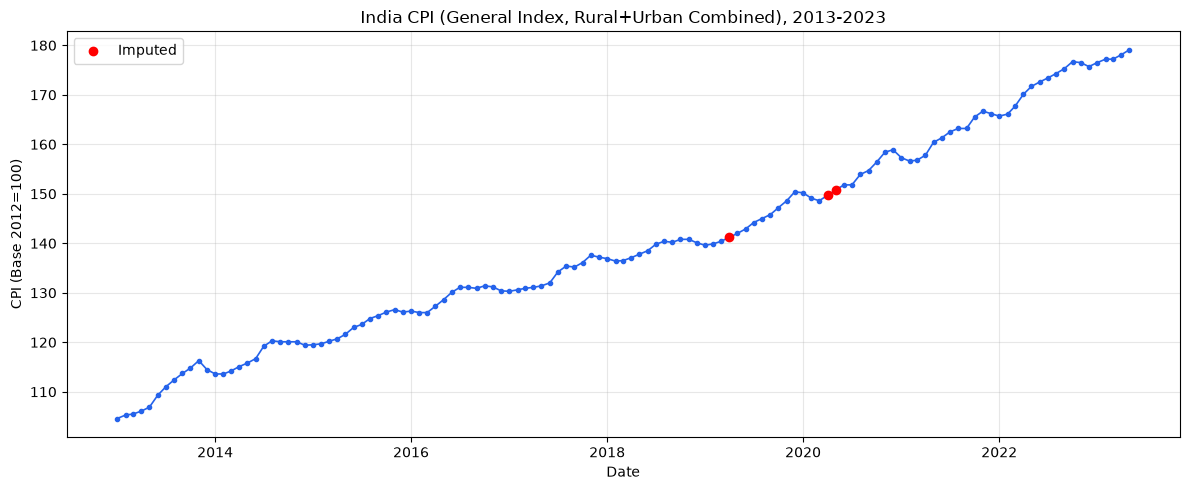

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(cpi['date'], cpi['cpi'], marker='o', markersize=3, linewidth=1.2, color='#2563eb')
imputed = cpi[cpi['cpi_imputed_flag']]
ax.scatter(imputed['date'], imputed['cpi'], color='red', zorder=5, label='Imputed')
ax.set_title('India CPI (General Index, Rural+Urban Combined), 2013-2023')
ax.set_xlabel('Date')
ax.set_ylabel('CPI (Base 2012=100)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/cpi_raw_plot.png', dpi=120)
plt.show()

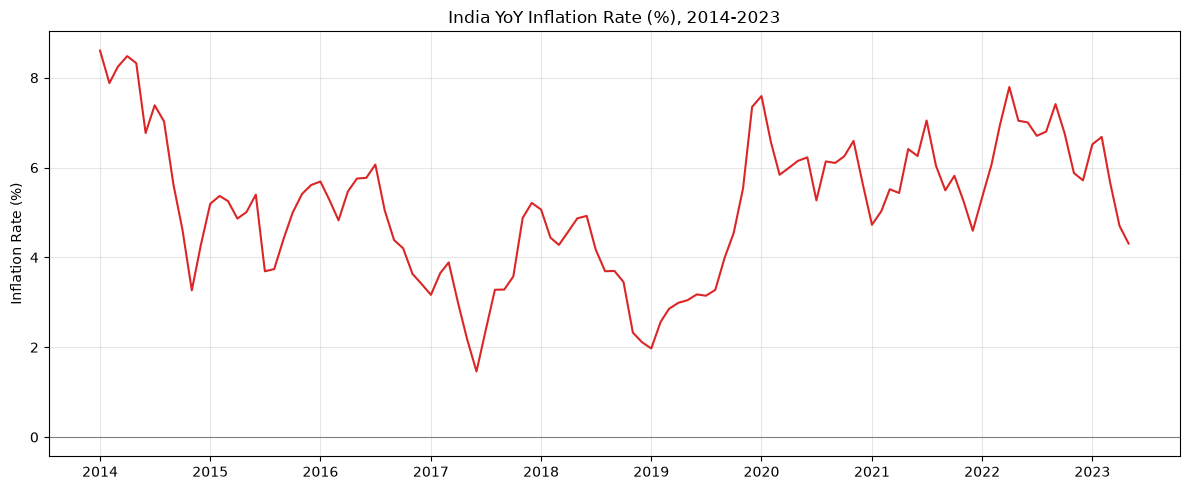

                             date  yoy_inflation
count                         113     113.000000
mean   2018-08-31 15:43:00.530973       5.136150
min           2014-01-01 00:00:00       1.460415
25%           2016-05-01 00:00:00       3.994294
50%           2018-09-01 00:00:00       5.253940
75%           2021-01-01 00:00:00       6.137931
max           2023-05-01 00:00:00       8.604207
std                           NaN       1.556298


In [9]:
cpi['yoy_inflation'] = cpi['cpi'].pct_change(12) * 100

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(cpi['date'], cpi['yoy_inflation'], color='#dc2626', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('India YoY Inflation Rate (%), 2014-2023')
ax.set_ylabel('Inflation Rate (%)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/yoy_inflation_plot.png', dpi=120)
plt.show()

print(cpi[['date','yoy_inflation']].dropna().describe())

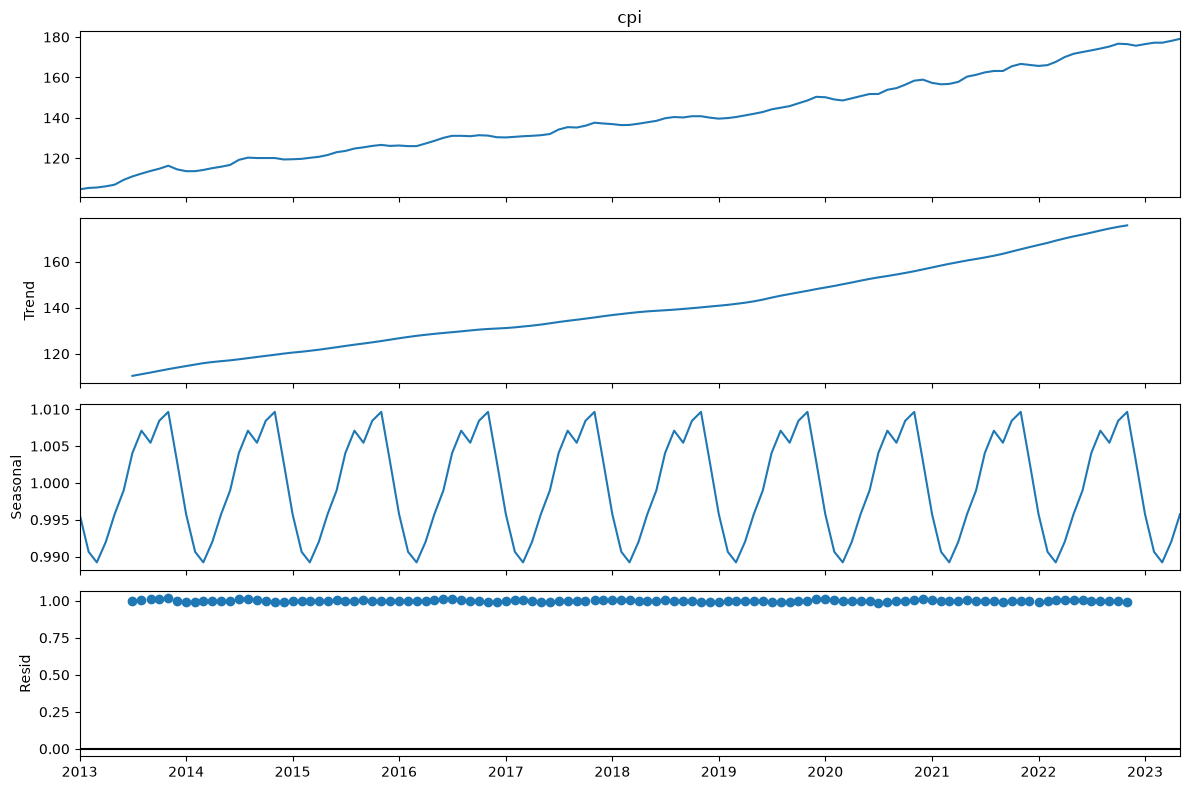

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

cpi_indexed = cpi.set_index('date')['cpi']
decomposition = seasonal_decompose(cpi_indexed, model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('../reports/decomposition_plot.png', dpi=120)
plt.show()

In [11]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(cpi_indexed.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Stationary" if result[1] < 0.05 else "Non-stationary (as expected for a trending series)")

ADF Statistic: 1.8384
p-value: 0.9984
Non-stationary (as expected for a trending series)


ADF Statistic (1st difference): -2.2133
p-value: 0.2015
Still non-stationary


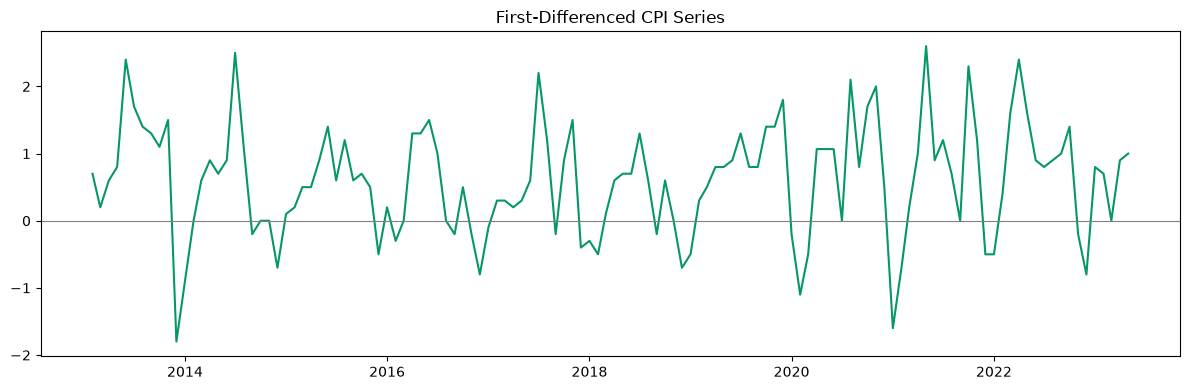

In [12]:
cpi_diff = cpi_indexed.diff().dropna()

result_diff = adfuller(cpi_diff)
print(f"ADF Statistic (1st difference): {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}")
print("Stationary" if result_diff[1] < 0.05 else "Still non-stationary")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(cpi_diff.index, cpi_diff.values, color='#059669')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('First-Differenced CPI Series')
plt.tight_layout()
plt.savefig('../reports/differenced_plot.png', dpi=120)
plt.show()

In [13]:
train = cpi_indexed[:-12]
test = cpi_indexed[-12:]

print("Train range:", train.index.min(), "to", train.index.max(), f"({len(train)} months)")
print("Test range:", test.index.min(), "to", test.index.max(), f"({len(test)} months)")

Train range: 2013-01-01 00:00:00 to 2022-05-01 00:00:00 (113 months)
Test range: 2022-06-01 00:00:00 to 2023-05-01 00:00:00 (12 months)


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive forecast: predict last known train value for every test point
naive_forecast = np.full(len(test), train.iloc[-1])

mae_naive = mean_absolute_error(test, naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test, naive_forecast))
mape_naive = np.mean(np.abs((test.values - naive_forecast) / test.values)) * 100

print(f"Naive Baseline — MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2f}%")

Naive Baseline — MAE: 4.35, RMSE: 4.71, MAPE: 2.46%


In [15]:
# Seasonal difference (subtract value from 12 months ago) on top of first difference
cpi_diff_seasonal = cpi_indexed.diff().diff(12).dropna()

result_seasonal = adfuller(cpi_diff_seasonal)
print(f"ADF Statistic (1st diff + seasonal diff): {result_seasonal[0]:.4f}")
print(f"p-value: {result_seasonal[1]:.4f}")
print("Stationary" if result_seasonal[1] < 0.05 else "Still non-stationary")

ADF Statistic (1st diff + seasonal diff): -4.2534
p-value: 0.0005
Stationary


In [16]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,                # monthly seasonality
    d=1, D=1,             # informed by our ADF tests
    trace=True,           # prints each model it tries
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=225.507, Time=1.10 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=255.140, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=229.188, Time=0.10 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=220.594, Time=0.13 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=250.859, Time=0.04 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=221.415, Time=0.19 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=221.060, Time=0.41 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=226.641, Time=0.10 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=222.695, Time=0.74 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=227.846, Time=0.09 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=222.494, Time=0.25 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=222.434, Time=0.16 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=222.466, Time=0.12 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=223.772, Time=0.30 sec
 ARIMA(0,1,1)(0,1,1)[12] intercep

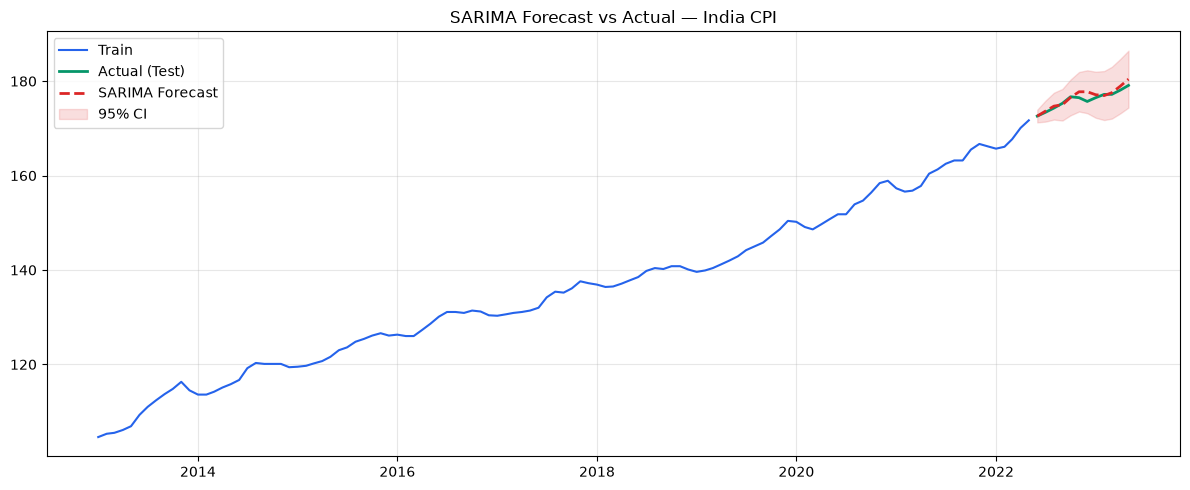

In [17]:
n_periods = len(test)
forecast, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index, train, label='Train', color='#2563eb')
ax.plot(test.index, test, label='Actual (Test)', color='#059669', linewidth=2)
ax.plot(test.index, forecast, label='SARIMA Forecast', color='#dc2626', linestyle='--', linewidth=2)
ax.fill_between(test.index, conf_int[:,0], conf_int[:,1], color='#dc2626', alpha=0.15, label='95% CI')
ax.legend()
ax.set_title('SARIMA Forecast vs Actual — India CPI')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/sarima_forecast_plot.png', dpi=120)
plt.show()

In [18]:
mae_sarima = mean_absolute_error(test, forecast)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast))
mape_sarima = np.mean(np.abs((test.values - forecast) / test.values)) * 100

print(f"SARIMA — MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2f}%")
print(f"Naive  — MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2f}%")

SARIMA — MAE: 0.65, RMSE: 0.87, MAPE: 0.37%
Naive  — MAE: 4.35, RMSE: 4.71, MAPE: 2.46%


In [19]:
from prophet import Prophet

prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=len(test), freq='MS')
prophet_forecast = m.predict(future)

# Extract just the test-period predictions
prophet_test_forecast = prophet_forecast.set_index('ds').loc[test.index, 'yhat']

Importing plotly failed. Interactive plots will not work.
11:14:58 - cmdstanpy - INFO - Chain [1] start processing
11:14:58 - cmdstanpy - INFO - Chain [1] done processing


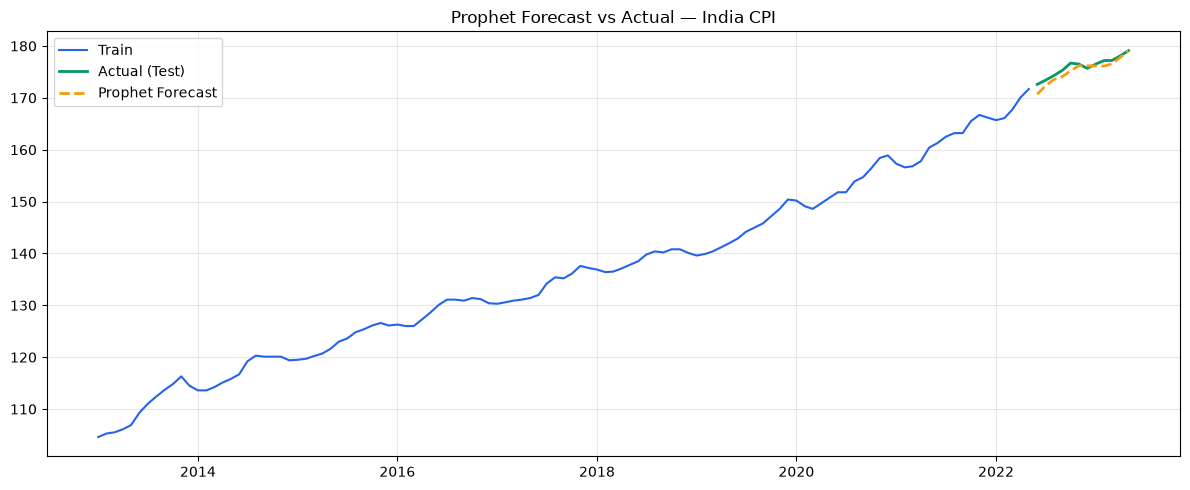

Prophet — MAE: 0.81, RMSE: 0.96, MAPE: 0.46%
SARIMA  — MAE: 0.65, RMSE: 0.87, MAPE: 0.37%
Naive   — MAE: 4.35, RMSE: 4.71, MAPE: 2.46%


In [20]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index, train, label='Train', color='#2563eb')
ax.plot(test.index, test, label='Actual (Test)', color='#059669', linewidth=2)
ax.plot(test.index, prophet_test_forecast, label='Prophet Forecast', color='#f59e0b', linestyle='--', linewidth=2)
ax.legend()
ax.set_title('Prophet Forecast vs Actual — India CPI')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/prophet_forecast_plot.png', dpi=120)
plt.show()

mae_prophet = mean_absolute_error(test, prophet_test_forecast)
rmse_prophet = np.sqrt(mean_squared_error(test, prophet_test_forecast))
mape_prophet = np.mean(np.abs((test.values - prophet_test_forecast.values) / test.values)) * 100

print(f"Prophet — MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}, MAPE: {mape_prophet:.2f}%")
print(f"SARIMA  — MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f}, MAPE: {mape_sarima:.2f}%")
print(f"Naive   — MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2f}%")

In [21]:
final_model = pm.auto_arima(
    cpi_indexed,
    seasonal=True,
    m=12,
    d=1, D=1,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

future_periods = 6  # forecasting 6 months beyond May 2023
future_forecast, future_conf_int = final_model.predict(n_periods=future_periods, return_conf_int=True)

future_dates = pd.date_range(cpi_indexed.index[-1] + pd.DateOffset(months=1), periods=future_periods, freq='MS')

forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_cpi': future_forecast,
    'lower_ci': future_conf_int[:,0],
    'upper_ci': future_conf_int[:,1]
})
print(forecast_df)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=248.807, Time=0.87 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=288.437, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=264.043, Time=0.18 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=244.965, Time=0.19 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=281.666, Time=0.03 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=246.955, Time=0.29 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=246.955, Time=0.35 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=259.957, Time=0.09 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=inf, Time=1.47 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=254.619, Time=0.11 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=246.614, Time=0.31 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=246.274, Time=0.21 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=248.538, Time=0.21 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=247.048, Time=0.34 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   

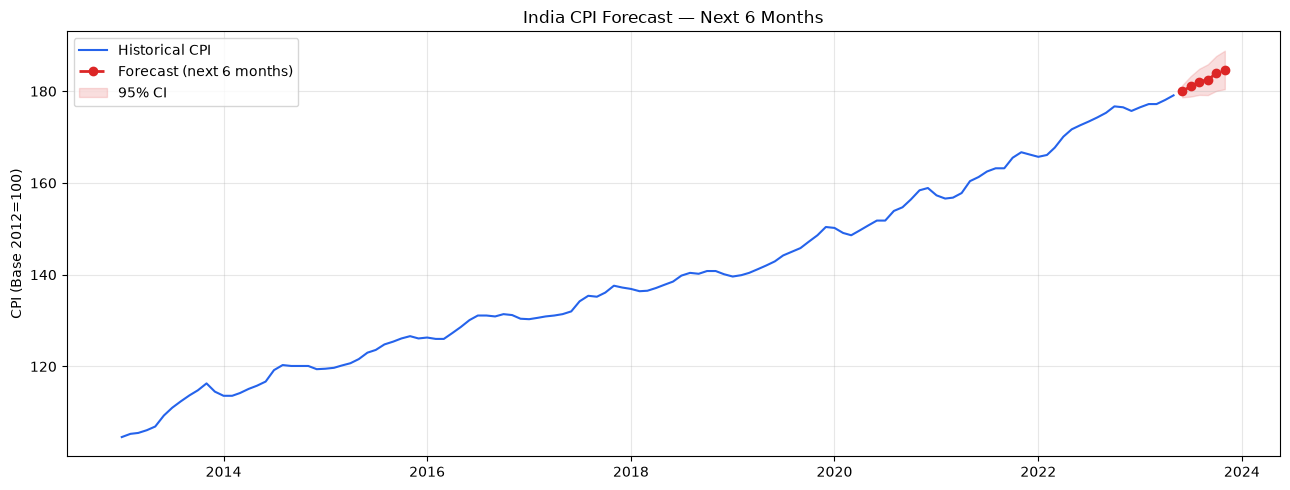

In [22]:
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(cpi_indexed.index, cpi_indexed, label='Historical CPI', color='#2563eb')
ax.plot(forecast_df['date'], forecast_df['forecast_cpi'], label='Forecast (next 6 months)', 
        color='#dc2626', linestyle='--', linewidth=2, marker='o')
ax.fill_between(forecast_df['date'], forecast_df['lower_ci'], forecast_df['upper_ci'], 
                color='#dc2626', alpha=0.15, label='95% CI')
ax.legend()
ax.set_title('India CPI Forecast — Next 6 Months')
ax.set_ylabel('CPI (Base 2012=100)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/final_forecast_plot.png', dpi=120)
plt.show()

In [23]:
# Implied YoY inflation for the forecast period
last_year_actuals = cpi_indexed[-12:].values
implied_inflation = ((forecast_df['forecast_cpi'].values - last_year_actuals[:future_periods]) / last_year_actuals[:future_periods]) * 100
forecast_df['implied_yoy_inflation_pct'] = implied_inflation
print(forecast_df[['date','forecast_cpi','implied_yoy_inflation_pct']])

                 date  forecast_cpi  implied_yoy_inflation_pct
2023-06-01 2023-06-01    179.988187                   4.280526
2023-07-01 2023-07-01    181.044401                   4.408536
2023-08-01 2023-08-01    182.051771                   4.447373
2023-09-01 2023-09-01    182.515196                   4.115913
2023-10-01 2023-10-01    183.870351                   4.057924
2023-11-01 2023-11-01    184.645023                   4.614744
